In [1]:
import numpy as np # generic math functions
from scipy.optimize import OptimizeResult, minimize
import matplotlib.pyplot as plt # plotting library
from typing import Sequence


from qiskit import QuantumCircuit, transpile

from qiskit_aer import AerSimulator
from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.circuit.library import efficient_su2, StatePreparation, EvolvedOperatorAnsatz, hamiltonian_variational_ansatz
#from qiskit_algorithms import VQE, VQEResult
#from qiskit_algorithms.minimum_eigensolvers import AdaptVQE, VQE
#from qiskit_algorithms.optimizers import COBYLA

In [2]:
Ns = np.array([4, 6, 8, 10]) # number of qubits
J = 1.0 # interaction strength
PBC = True # set to false for open boundary conditions
gs = np.linspace(-1.0, 1.0, 6) # transverse field strength

In [3]:
def H_tfi_qiskit(N, g=1.0, J=1.0, PBC=False):

    if PBC:
        J_zz = [("ZZ", [n, (n+1)%N], -J) for n in range(N)]
    else:
        J_zz = [("ZZ", [n, n+1], -J) for n in range(N-1)]
    
    g_field = [("X", [n], -g) for n in range(N)]
    
    operator_tuples = [*g_field, *J_zz]
    H =  SparsePauliOp.from_sparse_list(operator_tuples, num_qubits=N)
    return H.simplify()
    

In [4]:
# For real hardware:
"""
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2, Estimator
service = QiskitRuntimeService(channel="ibm_quantum")
backend = service.least_busy(operational=True, simulator=False)
estimator = Estimator(backend)
sampler = SamplerV2(backend)

"""

# For simulator
from qiskit_aer.primitives import SamplerV2, EstimatorV2
backend = AerSimulator(noise_model=None)
estimator = EstimatorV2()
sampler = SamplerV2()


In [5]:
### Corrected ansatz

def get_PBC_symm_ansatz(N, ref, num_layers=1):
    """Symmetry-preserving ansatz for the transverse field Ising model with periodic boundary conditions.
    
    Args:
        N (int): Number of qubits (spins).
        num_layers (int): Number of layers in the ansatz.
        Returns: Parametrized QuantumCircuit object representing the ansatz."""

    num_gates_per_layer = 3  # Rxx, Ryy, Rzz
    theta = ParameterVector('th', num_gates_per_layer * num_layers)
    phi = ParameterVector('phi', num_layers)

    symm_ansatz = QuantumCircuit(N)
    symm_ansatz.initialize(ref)
    symm_ansatz.h([n for n in range(N)])

    for layer in range(num_layers):
        for gate in ["xx", "yy", "zz"]:

            # Apply gates in brick structure
            # Even to odd connections
            for n in range(N //2):
                param_index = layer * num_gates_per_layer + ["xx", "yy", "zz"].index(gate)
                param = theta[param_index]
                
                if gate == "xx":
                    symm_ansatz.rxx(param, 2*n, 2*n+1)
                elif gate == "yy":
                    symm_ansatz.ryy(param, 2*n, 2*n+1)
                elif gate == "zz":
                    symm_ansatz.rzz(param, 2*n, 2*n+1)
            # Odd to even connections
            for n in range(1, N //2 +1):
                param_index = layer * num_gates_per_layer + ["xx", "yy", "zz"].index(gate)
                param = theta[param_index]
                
                if gate == "xx":
                    symm_ansatz.rxx(param, 2*n-1, (2*n)%N)
                elif gate == "yy":
                    symm_ansatz.ryy(param, 2*n-1, (2*n)%N)
                elif gate == "zz":
                    symm_ansatz.rzz(param, 2*n-1, (2*n)%N)
        # Apply RX gates
        symm_ansatz.rx(phi[layer], [n for n in range(N)])
    return symm_ansatz

In [6]:
def get_PBC_hva_ansatz(N, ref, h=0, num_layers=1):
    """Symmetry-preserving ansatz for the transverse field Ising model with periodic boundary conditions.
    
    Args:
        N (int): Number of qubits (spins).
        num_layers (int): Number of layers in the ansatz.
        Returns: Parametrized QuantumCircuit object representing the ansatz."""

    theta = ParameterVector('th',num_layers) # Does not depend on N
    phi = ParameterVector('phi', num_layers)
    lam = ParameterVector('lam', num_layers)
    

    hva_ansatz = QuantumCircuit(N)
    #hva_ansatz.append(StatePreparation(ref), range(N))
    hva_ansatz.initialize(ref)
    hva_ansatz.h([n for n in range(N)])

    for layer in range(num_layers):
        
        # Apply sigma gates in brick structure
        for n in range(N//2):
            hva_ansatz.rzz(theta[layer], 2*n, 2*n+1)
        for n in range(1, N//2 +1):
            hva_ansatz.rzz(theta[layer], 2*n-1, (2*n)%N)
        
        # The loop above only applies sigma gates between qubits 0 and N-1 if N is even.
        # To apply these gates when N is odd, manually apply a sigma gate between qubits 0 and N-1.
        if N % 2 == 1:
            hva_ansatz.rzz(theta[layer], N-1, 0)
            
        # Apply rx, rz gates
        hva_ansatz.rx(phi[layer], [n for n in range(N)])
        if h != 0:
            hva_ansatz.rz(theta[layer], [n for n in range(N)])
        
    return hva_ansatz


In [7]:
def cost_func(params, ansatze, hamiltonian, estimator, w):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatze (list): List of parameterized ansatz circuits with different reference states
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        w (ndarray): Array of weights for each ansatz in the cost function
    Returns:
        float: weighted sum of expectation values for each ansatz
    """
    pubs = []
    for ansatz in ansatze:
        pubs.append( (ansatz, [hamiltonian], params) )
    job = estimator.run(pubs, precision=1e-6)
    result = job.result()
    cost = 0 
    for i in range(len(result)):
        cost += w[i] * result[i].data.evs[0]
    
    
    return cost

In [8]:
def get_vqe_gs(ansatze, hamiltonian, estimator, w, num_runs=1):

    num_params = ansatze[0].num_parameters
    
    estimator.options.default_shots = 5000
    options = {'maxiter': 5000, 'rhobeg': 0.1, 'tol': 1e-6}

    best_cost = np.inf
    for seed in range(num_runs):
        x0 = np.random.randn(num_params)   # near zero
        res = minimize(
            cost_func,
            x0,
            args=(ansatze, hamiltonian, estimator, w),
            method="cobyla",
            options=options
        )
        if res.fun < best_cost:
            best_cost = res.fun
            theta_star = res.x
        
    return theta_star


In [9]:
k = 2 # number of eigenstates to approximate
w = np.arange(k, 0, -1) # weights in decreasing order, always positive
print(f"Weights assigned to each reference state: \n {w}")


Weights assigned to each reference state: 
 [2 1]


## Prepare ansatze and operators

In [10]:
ansatze_dict = {}
hamiltonians_dict = {}

for N in Ns:
    ground_ref = np.zeros(2**N)
    ground_ref[0] = 1.0  # |000...0>

    first_excited_ref = np.zeros(2**N)
    for i in range(N):
        first_excited_ref[2**i] = 1.0/np.sqrt(N)  # normalized superposition of |100..0>, |010..0>, ..., |000..1>

    refs = [ground_ref, first_excited_ref]
    ansatze_dict[N] = [get_PBC_symm_ansatz(N, ref, num_layers=N//2 +1) for ref in refs]  
    
    for g in gs:
        hamiltonians_dict[(N, g)] = H_tfi_qiskit(N, g=g, J=J, PBC=True)
        

## Run SSVQE 

In [11]:
theta_stars_dict = {}

for N in Ns:
    for g in gs:
        hamiltonian = hamiltonians_dict[(N, g)]
        ansatze = ansatze_dict[N]
        theta_star = get_vqe_gs(ansatze, hamiltonian, estimator, w, num_runs=3)
        theta_stars_dict[(N, g)] = theta_star
    

## Postprocessing

In [12]:
eigenvalues_qiskit = np.zeros( (len(Ns), len(gs), k) )
eigenstates_qiskit = {}

for i, N in enumerate(Ns):
    
    eigenstates_qiskit[N] = np.zeros((len(gs), k, 2**N), dtype=complex)
    for j, g in enumerate(gs):
        hamiltonian = hamiltonians_dict[(N, g)]
        ansatze = ansatze_dict[N]
        theta_star = theta_stars_dict[(N, g)]
        
        pubs = []
        for l, ansatz in enumerate(ansatze):
            bound_circuit = ansatz.assign_parameters(theta_star)
            sv = Statevector(bound_circuit)
            eigenstates_qiskit[N][j, l, :] = sv.data
            pubs.append( (bound_circuit, [hamiltonian]) )
        job = estimator.run(pubs, precision=1e-6)
        result = job.result()
        
        eigenvalues_qiskit[i, j, :] = [result[i].data.evs[0] for i in range(len(result))]


In [13]:
mass_gaps_qiskit = eigenvalues_qiskit[:, :, 1] - eigenvalues_qiskit[:, :, 0]

## Compare with QuSpin

In [14]:
import numpy as np # generic math functions
#from scipy.optimize import curve_fit
#from scipy.special import ellipk, factorial
#from scipy.integrate import quad

import matplotlib.pyplot as plt # plotting library
#plt.rcParams["text.usetex"] = True


import time, itertools
import sys,os
os.environ['OMP_NUM_THREADS'] = '8'
os.environ['MLK_NUM_THREADS'] = '8'

from quspin.operators import hamiltonian, quantum_operator, exp_op # Hamiltonians and operators
from quspin.basis import tensor_basis, spin_basis_1d, boson_basis_1d, boson_basis_general  # Hilbert space bases

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D # Required for 3D projection


In [15]:
##### define model parameters #####

def H_tfi_quspin(N, J=1.0, g=1.0, PBC=False): 
    basis_spin = spin_basis_1d(L=N)
    
    g_field=[[-g,i] for i in range(N)]
    
    if PBC:
        J_zz=[[-J, i, (i+1) % N] for i in range(N)]
    else:
        J_zz=[[-J, i, i+1] for i in range(N-1)] 
    static_spin = [["zz", J_zz], ["x", g_field]]
    dynamic_spin = []
    
    H_spin=hamiltonian(static_spin, dynamic_spin, basis=basis_spin, dtype=np.complex64, check_herm=False, check_symm=False)
    return H_spin

In [29]:
dense = True
gs = np.linspace(-1, 1, 30) # transverse field strength
eigenvalues_quspin = np.zeros((len(Ns), len(gs), k))
eigenstates_quspin = {}

for i, N in enumerate(Ns):
    eigenstates_quspin[N] = np.zeros((len(gs), k, 2**N), dtype=complex)
    for j, g in enumerate(gs):
        H = H_tfi_quspin(int(N), J=1.0, g=g, PBC=PBC)
        if dense:
            E, V = H.as_dense_format().eigh()
        else:
            E, V = H.eigsh(k=k, which='SA')
        
        eigenvalues_quspin[i, j, :] = E[:k]
        for l in range(k):
            eigenstates_quspin[N][j, l, :] = V[:, l]



mass_gaps_quspin = eigenvalues_quspin[:, :, 1] - eigenvalues_quspin[:, :, 0]

In [17]:
fractional_error = np.abs((np.array(eigenvalues_qiskit) - eigenvalues_quspin)/eigenvalues_quspin)

fidelity_arr = np.zeros((len(Ns), len(gs), k))

for i, N in enumerate(Ns):
    for j in range(len(gs)):
        for l in range(k):
            overlap = np.abs(np.vdot(eigenstates_quspin[N][j, l, :], eigenstates_qiskit[N][j, l, :]))
            fidelity_arr[i, j, l] = overlap**2    

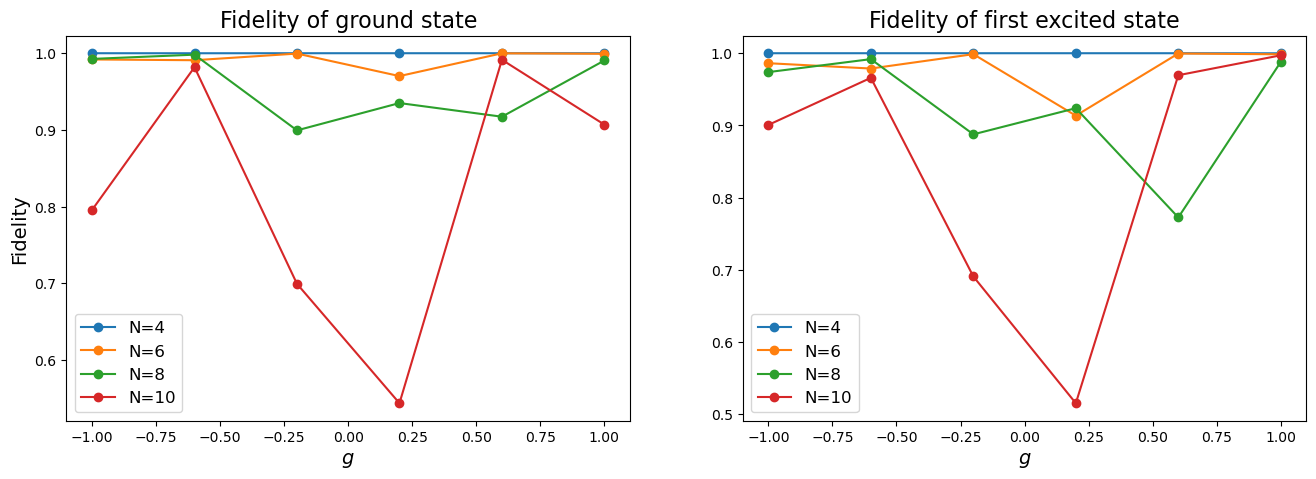

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(16,5))
for i, N in enumerate(Ns):
    ax[0].plot(gs, fidelity_arr[i, :, 0], marker='o', label=f'N={N}')
    ax[1].plot(gs, fidelity_arr[i, :, 1], marker='o', label=f'N={N}')

ax[0].set_xlabel('$g$', fontsize=14)
ax[0].set_ylabel('Fidelity', fontsize=14)
ax[0].set_title('Fidelity of ground state', fontsize=16)
ax[0].legend(fontsize=12)

ax[1].set_xlabel('$g$', fontsize=14)
ax[1].set_title('Fidelity of first excited state', fontsize=16)
ax[1].legend(fontsize=12)

plt.show()

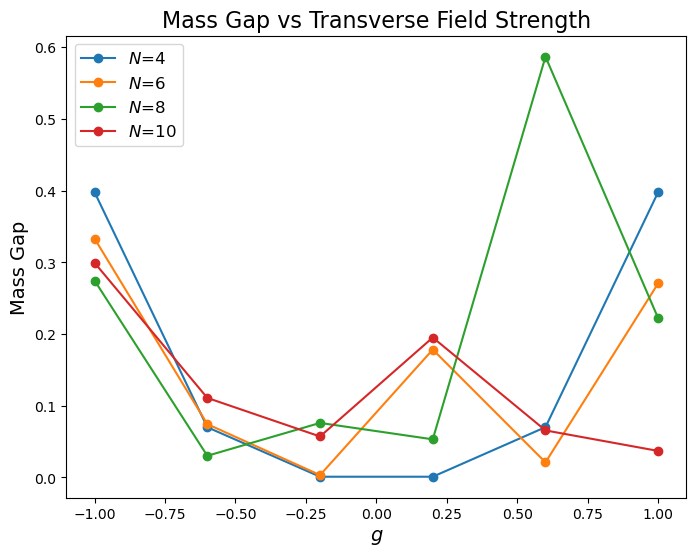

In [21]:
fig, ax = plt.subplots(figsize=(8,6))
for i, N in enumerate(Ns):
    ax.plot(gs, np.abs(mass_gaps_qiskit[i, :]), marker='o', label=f'$N$={N}')
    #ax.plot(gs, mass_gaps_quspin[i, :], label=f'N={N}')
ax.set_xlabel('$g$', fontsize=14)
ax.set_ylabel('Mass Gap', fontsize=14)
ax.set_title('Mass Gap vs Transverse Field Strength', fontsize=16)
ax.legend(fontsize=12)
plt.show()

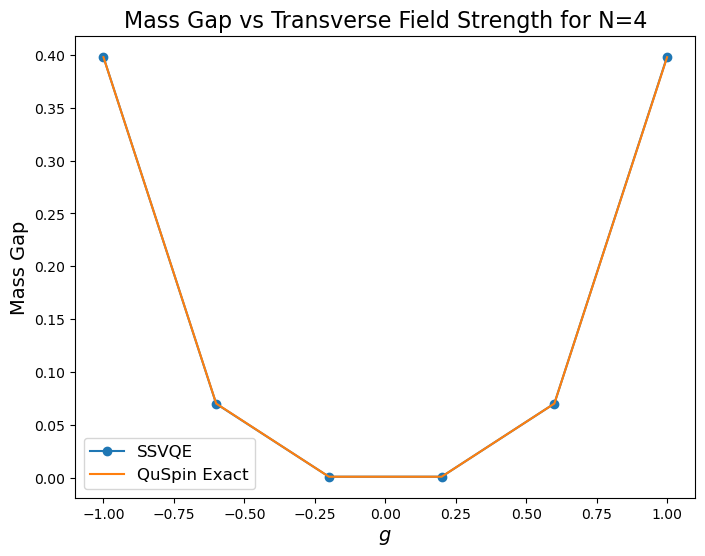

In [20]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(gs, mass_gaps_qiskit[0, :], marker='o', label='SSVQE')
ax.plot(gs, mass_gaps_quspin[0, :], label='QuSpin Exact')
ax.set_xlabel('$g$', fontsize=14)
ax.set_ylabel('Mass Gap', fontsize=14)
ax.set_title('Mass Gap vs Transverse Field Strength for N=4', fontsize=16)
ax.legend(fontsize=12)
plt.show()

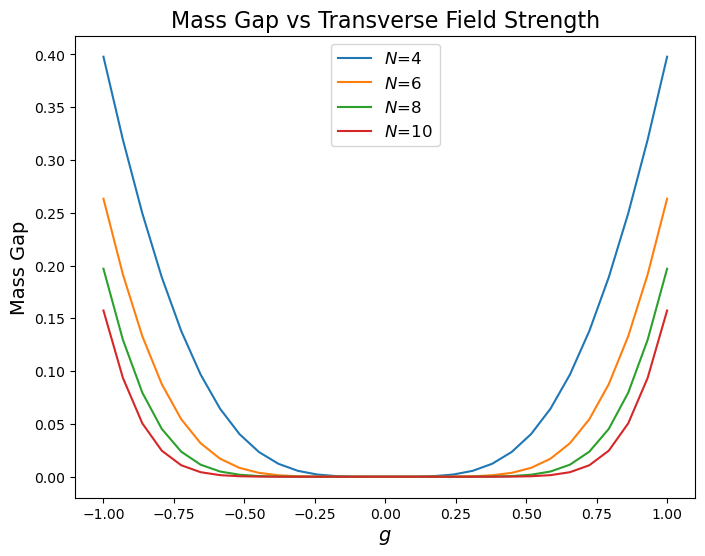

In [30]:
fig, ax = plt.subplots(figsize=(8,6))
for i, N in enumerate(Ns):
    ax.plot(gs, mass_gaps_quspin[i,:], label=f'$N$={N}')
ax.set_xlabel('$g$', fontsize=14)
ax.set_ylabel('Mass Gap', fontsize=14)
ax.set_title('Mass Gap vs Transverse Field Strength', fontsize=16)
ax.legend(fontsize=12)
plt.show()

array([5.35133362e-01, 4.12586212e-01, 3.03838730e-01, 2.11759567e-01,
       1.38333321e-01, 8.38642120e-02, 4.66661453e-02, 2.34961510e-02,
       1.04804039e-02, 4.00447845e-03, 1.23929977e-03, 2.80857086e-04,
       3.81469727e-05, 1.90734863e-06, 3.81469727e-06, 3.81469727e-06,
       1.90734863e-06, 3.81469727e-05, 2.80857086e-04, 1.23929977e-03,
       4.00447845e-03, 1.04804039e-02, 2.34961510e-02, 4.66661453e-02,
       8.38642120e-02, 1.38333321e-01, 2.11759567e-01, 3.03838730e-01,
       4.12586212e-01, 5.35133362e-01])